# SENTINEL-WM  |  Phase 2 - Network State Construction + Sequences

`clean_flows.parquet`  ->  `state_windows.parquet`  ->  `sequences.npz`

This is where flow classification becomes **state-trajectory modelling**:

1. every flow is bucketed into a 10 s window (`config.WindowConfig`),
2. flows in a window are aggregated into one ~40-dim **state vector S_t**,
3. each window gets a **progression state** (NORMAL / PRE_ATTACK / ONSET /
   ACTIVE / CONTINUATION) derived from the attack timeline - *this* is the
   model's primary target, not the ATT&CK tactic,
4. a two-layer **ATT&CK phase** + confidence is attached (`attack_stages.py`),
5. windows are cut into `[S_{t-9..t}] -> (S_{t+1}, A_{t+1..t+6}, Z_{t+1..t+6})`
   sequences with a leakage-safe split and a train-only RobustScaler.

In [1]:
# bootstrap: make the sentinel_wm package importable without pip install
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / 'sentinel_wm').is_dir() else _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sentinel_wm import config as C, state_windows as SW, sequences as SEQ
from sentinel_wm import attack_stages as A

## 2.1  Build the state windows

In [3]:
sw = SW.build_state_windows(verbose=True)
sw[['day','window_index','flow_count','attack_ratio','progression_state',
    'dominant_family','attck_phase','attck_confidence']].head(12)

[windows] W=10s stride=10s pre_attack_span=3


[windows] 3,035 state windows -> C:\Users\chall\OneDrive\Desktop\SIH\artifacts\state_windows.parquet
[windows] progression_state:
NORMAL          2566
    ACTIVE           350
    PRE_ATTACK        80
    ONSET             34
    CONTINUATION       5
[windows] y_attack balance: 0.128 positive
[windows] ATT&CK phase x confidence:
attck_phase     attck_confidence
    Impact          High                 228
                    Medium               150
    Initial Access  Low                   11
    None            High                2566
    Reconnaissance  Low                   80


,day,window_index,flow_count,attack_ratio,progression_state,dominant_family,attck_phase,attck_confidence
0,Wednesday,0,137.0,0.0,NORMAL,BENIGN,None,High
1,Wednesday,1,23.0,0.0,NORMAL,BENIGN,None,High
2,Wednesday,2,46.0,0.0,NORMAL,BENIGN,None,High
3,Wednesday,3,23.0,0.0,NORMAL,BENIGN,None,High
4,Wednesday,4,60.0,0.0,NORMAL,BENIGN,None,High
5,Wednesday,5,89.0,0.0,NORMAL,BENIGN,None,High
6,Wednesday,6,42.0,0.0,NORMAL,BENIGN,None,High
7,Wednesday,7,24.0,0.0,NORMAL,BENIGN,None,High
8,Wednesday,8,50.0,0.0,NORMAL,BENIGN,None,High
9,Wednesday,9,114.0,0.0,NORMAL,BENIGN,None,High


## 2.2  How the progression state is derived
`_derive_progression` walks each day, groups consecutive attack windows into
**episodes** (bridging <= `episode_gap_windows` benign holes), then labels:

| condition | state |
|---|---|
| no malicious flow | NORMAL |
| benign, <= `pre_attack_span` windows before an onset, contiguous in time | PRE_ATTACK |
| first window of an episode | ONSET |
| sustained, same dominant family | ACTIVE |
| dominant family changed / trailing edge with falling ratio | CONTINUATION |

In [4]:
sw['progression_state'].value_counts()

NORMAL          2566
ACTIVE           350
PRE_ATTACK        80
ONSET             34
CONTINUATION       5
Name: progression_state, dtype: int64

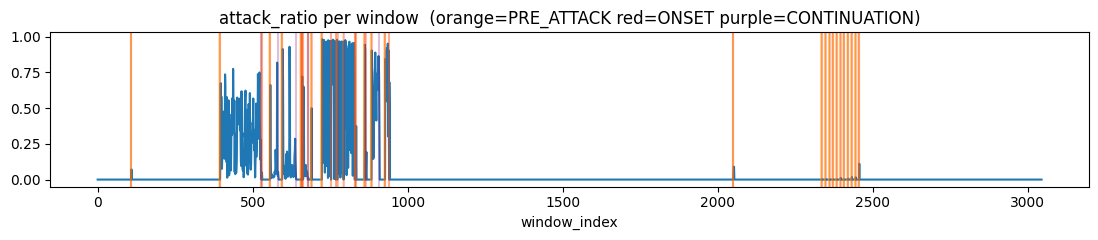

In [5]:
d0 = sw[sw.day == sw.day.iloc[0]].set_index('window_index')
ax = d0[['attack_ratio']].plot(figsize=(11,2.5), legend=False)
for st,c in [('PRE_ATTACK','orange'),('ONSET','red'),('CONTINUATION','purple')]:
    for x in d0.index[d0.progression_state==st]: ax.axvline(x, color=c, alpha=.25)
ax.set_title('attack_ratio per window  (orange=PRE_ATTACK red=ONSET purple=CONTINUATION)')
plt.tight_layout()

## 2.3  The ATT&CK phase mapping  (the part reviewers challenge first)

CIC-IDS-2017 labels a *flow* (`DoS Hulk`), never a *tactic per moment*. So the
mapping is a deterministic **two-layer** function applied AFTER the model:

* **Layer A** - `CIC_LABEL_TO_ATTACK`: `attack_family -> tactic, technique IDs,
  base confidence`. Literature, not learned.
* **Layer B** - `assess_window(progression_state, family, prev_family, ratio)`:
  resolves one window to a single phase and **lowers confidence whenever the
  evidence is weak** (PRE_ATTACK, ONSET, low ratio, long forecast horizon).

Every row carries `attck_confidence` in {High, Medium, Low} and a `attck_rationale`.

In [6]:
A._self_test()
for ps in ['NORMAL','PRE_ATTACK','ONSET','ACTIVE','CONTINUATION']:
    a = A.assess_window(ps, 'DoS Hulk', prev_family='DoS slowloris', attack_ratio=0.6)
    print(f"{ps:13s} -> {a.kill_chain_phase:20s} {a.confidence:7s} | {a.rationale[:70]}")

attack_stages self-test: PASS
NORMAL        -> None                 High    | window contains only BENIGN flows
PRE_ATTACK    -> Reconnaissance       Low     | benign window immediately preceding a DoS Hulk onset; no confirmed mal
ONSET         -> Impact               Medium  | first window carrying a confirmed DoS Hulk label; tactic per knowledge
ACTIVE        -> Impact               High    | sustained DoS Hulk activity (attack_ratio=0.60); HTTP flood -> endpoin
CONTINUATION  -> Impact               Medium  | tactic transition DoS slowloris -> DoS Hulk; adversary changed techniq


In [7]:
sw.groupby(['attck_phase','attck_confidence']).size().to_frame('n')

n
attck_phase    attck_confidence      
Impact         High               228
               Medium             150
Initial Access Low                 11
None           High              2566
Reconnaissance Low                 80

In [8]:
# a worked forecast row: progression-head says 60% ACTIVE at +60s
A.assess_forecast([0.1,0.1,0.05,0.6,0.15], horizon_k=6,
                  dominant_family_hint='DoS Hulk', attack_prob=0.72).to_dict()

{'progression_state': 'ACTIVE',
 'mitre_tactic': 'Impact',
 'technique_ids': ['T1499', 'T1499.002'],
 'kill_chain_phase': 'Impact',
 'confidence': 'Low',
 'rationale': 'forecast +60s (step k=6); P(state)=0.60, P(attack)=0.72. sustained DoS Hulk activity (attack_ratio=0.72); HTTP flood -> endpoint DoS',
 'dominant_family': 'DoS Hulk',
 'family_transition': None}

## 2.4  Cut sequences + leakage-safe split

Single CIC-IDS-2017 day -> a plain chronological cut puts whole attack
episodes on one side. `assign_split` therefore defaults to **block-interleaved**
(5-min blocks -> train/train/train/val/test) so every split contains attack
windows. It auto-switches to the proposal's **day-based** split (Mon-Wed / Thu /
Fri) the moment more than one day is present. Scaler is fit on TRAIN only.

In [9]:
seq = SEQ.build_sequences(verbose=True)
print('X', seq['X'].shape, ' y_atk', seq['y_atk'].shape, ' K', int(seq['K']))

[split] mode=block  days=['Wednesday']


[seq] train:   1800 seqs | y_atk(any k)+ = 0.169 | k1+ = 0.136
[seq] val  :    575 seqs | y_atk(any k)+ = 0.148 | k1+ = 0.078
[seq] test :    594 seqs | y_atk(any k)+ = 0.202 | k1+ = 0.160
[seq] X shape (2969, 10, 41) -> C:\Users\chall\OneDrive\Desktop\SIH\artifacts\sequences.npz
[seq] scaler -> C:\Users\chall\OneDrive\Desktop\SIH\artifacts\state_scaler.pkl
X (2969, 10, 41)  y_atk (2969, 6)  K 6


[split] mode=block  days=['Wednesday']


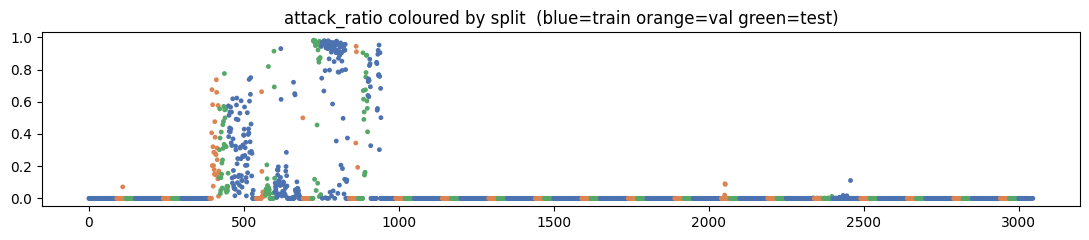

In [10]:
sw2 = sw.copy(); sw2['split'] = SEQ.assign_split(sw2, C.CONFIG.split, C.CONFIG.window)
d0 = sw2[sw2.day==sw2.day.iloc[0]]
fig, ax = plt.subplots(figsize=(11,2.5))
colors = {'train':'#4c72b0','val':'#dd8452','test':'#55a868'}
ax.scatter(d0.window_index, d0.attack_ratio, c=d0.split.map(colors), s=6)
ax.set_title('attack_ratio coloured by split  (blue=train orange=val green=test)')
plt.tight_layout()

---
Next: **`model_train.ipynb`** - logistic-regression / random-forest baselines,
then the Temporal-Transformer world model, then the benchmark table.